In [1]:
import keras
from keras.datasets import mnist
import numpy as np

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

train_images_with_noise_channels = np.concatenate(
    [train_images, np.random.random((len(train_images), 784))],axis=1)
train_images_with_zeros_channels = np.concatenate(
    [train_images, np.zeros((len(train_images), 784))], axis=1)

In [2]:
import keras
from keras import layers

def get_model():
    model = keras.Sequential([
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(optimizer="rmsprop",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

    return model

model = get_model()
history_noise = model.fit(
    train_images_with_noise_channels, train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

model = get_model()
history_zeros = model.fit(
    train_images_with_zeros_channels, train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)



Epoch 1/10


375/375 [==============================] - 8s 16ms/step - loss: 0.6089 - accuracy: 0.8145 - val_loss: 0.3463 - val_accuracy: 0.8807
Epoch 2/10
375/375 [==============================] - 5s 12ms/step - loss: 0.2502 - accuracy: 0.9243 - val_loss: 0.1777 - val_accuracy: 0.9489
Epoch 3/10
375/375 [==============================] - 5s 15ms/step - loss: 0.1641 - accuracy: 0.9489 - val_loss: 0.1510 - val_accuracy: 0.9553
Epoch 4/10
375/375 [==============================] - 5s 14ms/step - loss: 0.1171 - accuracy: 0.9628 - val_loss: 0.1536 - val_accuracy: 0.9565
Epoch 5/10
375/375 [==============================] - 5s 15ms/step - loss: 0.0855 - accuracy: 0.9728 - val_loss: 0.1552 - val_accuracy: 0.9536
Epoch 6/10
375/375 [==============================] - 5s 14ms/step - loss: 0.0619 - accuracy: 0.9808 - val_loss: 0.1357 - val_accuracy: 0.9627
Epoch 7/10
375/375 [==============================] - 5s 15ms/step - loss: 0.0463 - accuracy: 0.9859 - val_loss: 0.1269 - val_accuracy: 0.

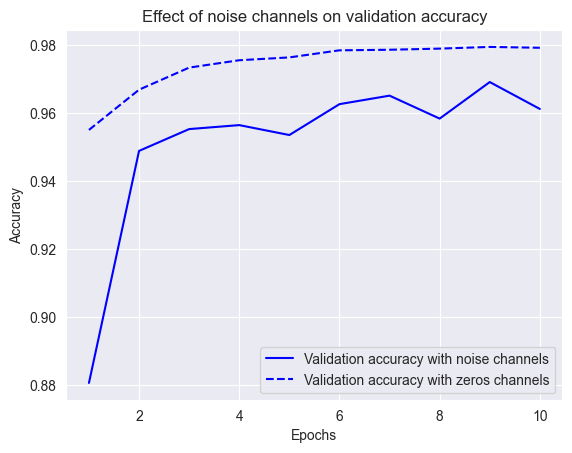

In [3]:
import matplotlib.pyplot as plt
val_acc_noise = history_noise.history["val_accuracy"]
val_acc_zeros = history_zeros.history["val_accuracy"]
epochs = range(1, 11)
plt.plot(epochs,val_acc_noise,"b-",
         label = "Validation accuracy with noise channels")
plt.plot(epochs,val_acc_zeros,"b--",
         label = "Validation accuracy with zeros channels")
plt.title("Effect of noise channels on validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

In [4]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

random_train_labels = train_labels[:]
np.random.shuffle(random_train_labels)

model = keras.Sequential([
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.fit(train_images, random_train_labels,
          epochs=100,
          batch_size=128,
          validation_split=0.2)

Epoch 1/100
375/375 [==============================] - 5s 12ms/step - loss: 2.3153 - accuracy: 0.1049 - val_loss: 2.3037 - val_accuracy: 0.1083
Epoch 2/100
375/375 [==============================] - 5s 13ms/step - loss: 2.2993 - accuracy: 0.1176 - val_loss: 2.3094 - val_accuracy: 0.0988
Epoch 3/100
375/375 [==============================] - 4s 12ms/step - loss: 2.2922 - accuracy: 0.1265 - val_loss: 2.3152 - val_accuracy: 0.1032
Epoch 4/100
375/375 [==============================] - 4s 11ms/step - loss: 2.2803 - accuracy: 0.1389 - val_loss: 2.3279 - val_accuracy: 0.1021
Epoch 5/100
375/375 [==============================] - 4s 11ms/step - loss: 2.2649 - accuracy: 0.1511 - val_loss: 2.3300 - val_accuracy: 0.1021
Epoch 6/100
375/375 [==============================] - 5s 12ms/step - loss: 2.2454 - accuracy: 0.1671 - val_loss: 2.3442 - val_accuracy: 0.1038
Epoch 7/100
375/375 [==============================] - 4s 12ms/step - loss: 2.2226 - accuracy: 0.1800 - val_loss: 2.3588 - val_accuracy:

In [5]:
(train_images,train_labels), _= mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

model = keras.Sequential([
    layers.Dense(512,activation="relu"),
    layers.Dense(10,activation="softmax")
])
model.compile(optimizer=keras.optimizers.RMSprop(1.),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.fit(train_images,train_labels,
          epochs=10,
          batch_size=128,
          validation_split=0.2)

Epoch 1/10
375/375 [==============================] - 5s 13ms/step - loss: 674.2186 - accuracy: 0.3055 - val_loss: 2.2293 - val_accuracy: 0.2181
Epoch 2/10
375/375 [==============================] - 4s 11ms/step - loss: 2.6755 - accuracy: 0.1982 - val_loss: 2.2545 - val_accuracy: 0.1875
Epoch 3/10
375/375 [==============================] - 4s 10ms/step - loss: 3.4053 - accuracy: 0.1996 - val_loss: 2.3682 - val_accuracy: 0.1171
Epoch 4/10
375/375 [==============================] - 4s 10ms/step - loss: 2.4475 - accuracy: 0.1586 - val_loss: 2.3519 - val_accuracy: 0.1312
Epoch 5/10
375/375 [==============================] - 4s 10ms/step - loss: 2.3571 - accuracy: 0.1712 - val_loss: 2.2769 - val_accuracy: 0.1832
Epoch 6/10
375/375 [==============================] - 4s 11ms/step - loss: 2.3603 - accuracy: 0.1728 - val_loss: 2.2608 - val_accuracy: 0.1854
Epoch 7/10
375/375 [==============================] - 4s 11ms/step - loss: 2.3382 - accuracy: 0.1636 - val_loss: 2.4449 - val_accuracy: 0.17

In [6]:
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10,activation="softmax")
])

model.compile(optimizer=keras.optimizers.RMSprop(1e-2),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.fit(train_images,train_labels,
          epochs=10,
          batch_size=128,
          validation_split=0.2)

Epoch 1/10
375/375 [==============================] - 5s 11ms/step - loss: 0.3497 - accuracy: 0.9112 - val_loss: 0.1256 - val_accuracy: 0.9641
Epoch 2/10
375/375 [==============================] - 4s 12ms/step - loss: 0.1243 - accuracy: 0.9640 - val_loss: 0.1401 - val_accuracy: 0.9649
Epoch 3/10
375/375 [==============================] - 4s 12ms/step - loss: 0.0967 - accuracy: 0.9739 - val_loss: 0.2989 - val_accuracy: 0.9393
Epoch 4/10
375/375 [==============================] - 4s 10ms/step - loss: 0.0797 - accuracy: 0.9793 - val_loss: 0.1426 - val_accuracy: 0.9693
Epoch 5/10
375/375 [==============================] - 4s 10ms/step - loss: 0.0677 - accuracy: 0.9824 - val_loss: 0.1533 - val_accuracy: 0.9700
Epoch 6/10
375/375 [==============================] - 4s 10ms/step - loss: 0.0584 - accuracy: 0.9856 - val_loss: 0.2357 - val_accuracy: 0.9653
Epoch 7/10
375/375 [==============================] - 4s 10ms/step - loss: 0.0594 - accuracy: 0.9863 - val_loss: 0.2002 - val_accuracy: 0.9704

In [7]:
model = keras.Sequential([layers.Dense(10,activation="softmax")])

model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history_small_model = model.fit(train_images,train_labels,
          epochs=20,
          batch_size=128,
          validation_split=0.2)

Epoch 1/20
375/375 [==============================] - 2s 4ms/step - loss: 0.6611 - accuracy: 0.8407 - val_loss: 0.3622 - val_accuracy: 0.9021
Epoch 2/20
375/375 [==============================] - 1s 4ms/step - loss: 0.3535 - accuracy: 0.9026 - val_loss: 0.3083 - val_accuracy: 0.9150
Epoch 3/20
375/375 [==============================] - 2s 5ms/step - loss: 0.3181 - accuracy: 0.9118 - val_loss: 0.2920 - val_accuracy: 0.9199
Epoch 4/20
375/375 [==============================] - 2s 5ms/step - loss: 0.3022 - accuracy: 0.9161 - val_loss: 0.2837 - val_accuracy: 0.9197
Epoch 5/20
375/375 [==============================] - 2s 4ms/step - loss: 0.2923 - accuracy: 0.9178 - val_loss: 0.2769 - val_accuracy: 0.9236
Epoch 6/20
375/375 [==============================] - 2s 5ms/step - loss: 0.2856 - accuracy: 0.9200 - val_loss: 0.2742 - val_accuracy: 0.9253
Epoch 7/20
375/375 [==============================] - 2s 4ms/step - loss: 0.2807 - accuracy: 0.9216 - val_loss: 0.2706 - val_accuracy: 0.9261
Epoch 

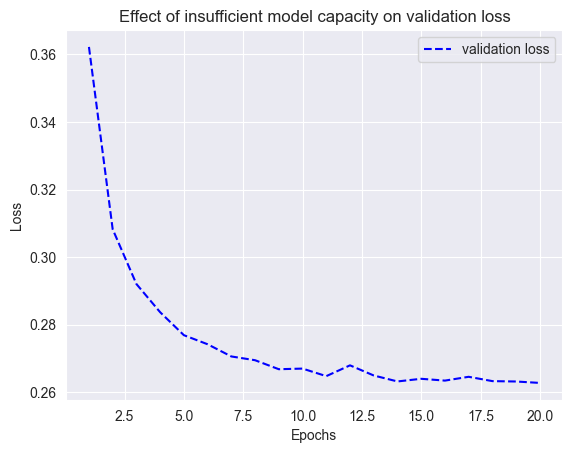

In [8]:
import  matplotlib.pyplot as plt
val_loss = history_small_model.history["val_loss"]
epochs = range(1,21)
plt.plot(epochs,val_loss,"b--",
         label="validation loss")
plt.title("Effect of insufficient model capacity on validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

In [9]:
model = keras.Sequential([
    layers.Dense(96,activation="relu"),
    layers.Dense(96,activation="relu"),
    layers.Dense(10,activation="softmax")
])

model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history_large_model = model.fit(train_images,train_labels,
          epochs=20,
          batch_size=128,
          validation_split=0.2)

Epoch 1/20
375/375 [==============================] - 4s 7ms/step - loss: 0.3560 - accuracy: 0.8998 - val_loss: 0.1750 - val_accuracy: 0.9488
Epoch 2/20
375/375 [==============================] - 2s 6ms/step - loss: 0.1584 - accuracy: 0.9536 - val_loss: 0.1840 - val_accuracy: 0.9439
Epoch 3/20
375/375 [==============================] - 3s 7ms/step - loss: 0.1130 - accuracy: 0.9662 - val_loss: 0.1213 - val_accuracy: 0.9623
Epoch 4/20
375/375 [==============================] - 3s 8ms/step - loss: 0.0865 - accuracy: 0.9736 - val_loss: 0.0981 - val_accuracy: 0.9690
Epoch 5/20
375/375 [==============================] - 3s 8ms/step - loss: 0.0687 - accuracy: 0.9795 - val_loss: 0.0932 - val_accuracy: 0.9715
Epoch 6/20
375/375 [==============================] - 2s 7ms/step - loss: 0.0567 - accuracy: 0.9827 - val_loss: 0.0957 - val_accuracy: 0.9717
Epoch 7/20
375/375 [==============================] - 2s 7ms/step - loss: 0.0467 - accuracy: 0.9858 - val_loss: 0.1065 - val_accuracy: 0.9699
Epoch 

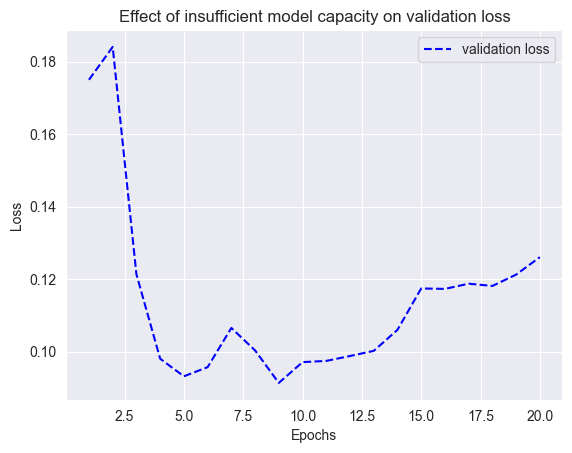

In [10]:
import  matplotlib.pyplot as plt
val_loss = history_large_model.history["val_loss"]
epochs = range(1,21)
plt.plot(epochs,val_loss,"b--",
         label="validation loss")
plt.title("Effect of insufficient model capacity on validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()